# Activation Steering for Truthful VLM



Collect activations at verified circuit heads on the train set, compute a

**truthful direction** per head, then steer the model at inference time on

the COCO val set to reduce hallucinations and missed detections.



## Steering formula



For each head $(l, h)$:



$$\vec{d}_{l,h} = (\mu_{TP} - \mu_{FP}) + (\mu_{TN} - \mu_{FN})$$



- $(\mu_{TP} - \mu_{FP})$ : push from hallucinated-yes toward genuine-yes

- $(\mu_{TN} - \mu_{FN})$ : push from missed-yes toward correct-no



At inference, we add $\alpha \cdot \vec{d}_{l,h}$ to head $(l,h)$'s pre-projection

activation at the last token position.

In [1]:
from nnsight import VisionLanguageModel
from PIL import Image
import json, os, gc, random, pickle
from pathlib import Path
import torch
import numpy as np
from transformers import BitsAndBytesConfig, AutoProcessor
from tqdm import tqdm
import matplotlib.pyplot as plt

print('Imports done.')

Imports done.


In [2]:
NB_DIR = Path(os.getcwd())  # mitigation/
PROJECT_DIR = NB_DIR.parent

MODEL_ID = 'llava-hf/llava-1.5-7b-hf'

# --- Train data (for collecting activations) ---
TRAIN_ANS_FILE   = PROJECT_DIR / 'results' / 'train' / 'llava15_7b_adversarial_train.jsonl'
TRAIN_LABEL_FILE = PROJECT_DIR / 'pope_train' / 'coco_train_pope_adversarial.jsonl'
TRAIN_IMAGE_ROOT = PROJECT_DIR / 'data' / 'coco2014' / 'train2014' / 'train2014'

# --- Val data (for evaluation) ---
# POPE eval uses val2014 images.  Download if missing.
VAL_POPE_FILE  = PROJECT_DIR / 'pope' / 'coco_pope_adversarial.json'
VAL_IMAGE_ROOT = PROJECT_DIR / 'data' / 'coco2014' / 'val2014' / 'val2014'

# --- Cache ---
CACHE_DIR = NB_DIR / 'cache'
CACHE_DIR.mkdir(exist_ok=True)
STEERING_VECTORS_PATH = CACHE_DIR / 'steering_vectors.pt'
ACTIVATIONS_PATH      = CACHE_DIR / 'category_activations.pt'
BASELINE_RESULTS_PATH = CACHE_DIR / 'baseline_val_results.jsonl'

# --- Collection config ---
# How many samples to collect from EACH of TP, TN, FP, FN.
# Total forward passes = N_COLLECT × 4.
# Clamped to pool size (TP=4654, TN=3333, FP=1668, FN=347).
N_COLLECT = 200

# Model constants
NUM_HEADS = 32
NUM_LAYERS = 32
HIDDEN_DIM = 4096
HEAD_DIM = HIDDEN_DIM // NUM_HEADS  # 128

print(f'Train images: {TRAIN_IMAGE_ROOT}  (exists: {TRAIN_IMAGE_ROOT.exists()})')
print(f'Val images:   {VAL_IMAGE_ROOT}  (exists: {VAL_IMAGE_ROOT.exists()})')
print(f'N_COLLECT = {N_COLLECT} per category  →  {N_COLLECT * 4} total forward passes')

Train images: /workspace/vlm-causality/data/coco2014/train2014/train2014  (exists: True)
Val images:   /workspace/vlm-causality/data/coco2014/val2014/val2014  (exists: True)
N_COLLECT = 200 per category  →  800 total forward passes


In [3]:
import re

def build_prompt(question_text: str) -> str:
    return f'USER: <image>\n{question_text}\nASSISTANT:'

def get_prob_diff(logits):
    """p(Yes) - p(No) from logits.  Positive -> model prefers Yes."""
    logits = logits[0, -1, :]
    probs = torch.softmax(logits.float(), dim=-1)
    return probs[yes_id].item() - probs[no_id]

def extract_answer(generated_text: str) -> str:
    """
    Parse 'yes' / 'no' from generated text using word-boundary regex,
    matching the heuristic from llava_infer_baseline.py::extract_answer().
    Returns 'yes', 'no', or 'unknown'.
    """
    text = generated_text.strip().lower()
    # Look for word-boundary yes/no in the first sentence
    first_sentence = text.split('.')[0]
    if re.search(r'\byes\b', first_sentence):
        return 'yes'
    if re.search(r'\bno\b', first_sentence):
        return 'no'
    # Fallback: search entire text
    if re.search(r'\byes\b', text):
        return 'yes'
    if re.search(r'\bno\b', text):
        return 'no'
    return 'unknown'

print('Helpers defined.')

Helpers defined.


In [4]:
# --- Load model + processor ---
model = VisionLanguageModel(
    'llava-hf/llava-1.5-7b-hf',
    device_map='cuda',
    dispatch=True,
)
processor = AutoProcessor.from_pretrained(MODEL_ID)
tokenizer = processor.tokenizer

# Token IDs for Yes / No
yes_id = tokenizer.encode('Yes', add_special_tokens=False)[0]
no_id  = tokenizer.encode('No',  add_special_tokens=False)[0]
print(f"'Yes' token id: {yes_id}, 'No' token id: {no_id}\n")
print(f'Model device: {model.device}')

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

'Yes' token id: 3869, 'No' token id: 1939

Model device: cuda:0


## 1. Load Train Data & Classify TP / TN / FP / FN

In [5]:
# --- Load model answers & labels, then classify ---
answers = []
with open(TRAIN_ANS_FILE) as f:
    for line in f:
        if line.strip():
            answers.append(json.loads(line))

labels = []
with open(TRAIN_LABEL_FILE) as f:
    for line in f:
        if line.strip():
            labels.append(json.loads(line))

label_by_qid = {l['question_id']: l for l in labels}

tp, tn, fp, fn = [], [], [], []
for ans in answers:
    qid = ans['question_id']
    lab = label_by_qid.get(qid)
    if lab is None:
        continue
    item = {'question_id': qid, 'image': lab['image'], 'text': lab['text'], 'label': lab['label']}
    if   lab['label'] == 'yes' and ans['answer'] == 'yes': tp.append(item)
    elif lab['label'] == 'no'  and ans['answer'] == 'no':  tn.append(item)
    elif lab['label'] == 'no'  and ans['answer'] == 'yes': fp.append(item)
    elif lab['label'] == 'yes' and ans['answer'] == 'no':  fn.append(item)

print(f'TP: {len(tp)} | TN: {len(tn)} | FP: {len(fp)} | FN: {len(fn)}')

TP: 4654 | TN: 3333 | FP: 1668 | FN: 347


## 2. Steering Heads



Union of all verified top heads from circuit discovery (Step 2).

These are the heads whose activations we steer.

In [6]:
# Verified top heads from circuit discovery (Step 2)
tp_top_heads = [(16, 0), (16, 15), (15, 31), (13, 4), (14, 20), (26, 4), (27, 7), (12, 1), (15, 30), (30, 31), (0, 3), (13, 30), (13, 28), (31, 27), (18, 26)]
tn_top_heads = [(13, 16), (16, 15), (14, 20), (13, 4), (16, 0), (0, 3), (14, 27), (13, 28), (14, 24), (15, 5), (0, 15), (14, 0), (15, 31), (1, 0), (15, 10)]
fp_top_heads = [(16, 0), (16, 15), (15, 31), (13, 4), (14, 20), (26, 4), (15, 30), (0, 3), (27, 7), (12, 1), (13, 16), (30, 31), (13, 30), (21, 25), (12, 3)]
fn_top_heads = [(13, 16), (0, 3), (16, 15), (14, 27), (14, 20), (0, 15), (14, 24), (13, 28), (13, 4), (15, 5), (1, 0), (13, 22), (18, 23), (7, 22), (14, 21)]

# ONE shared set — every category collects from the SAME heads
STEERING_HEADS = sorted(set(tp_top_heads + tn_top_heads + fp_top_heads + fn_top_heads))

STEERING_HEADS = [(1, 24), (1, 27), (2, 17), (2, 20), (11, 17), (7, 14), (10, 29), (11, 26), (11, 14), (8, 6), (8, 25), (12, 25), (6, 17), (11, 7), (11, 16), (13, 4), (13, 28), (14, 20), (15, 31), (16, 15), (16, 0)]
STEERING_HEADS.sort(key=lambda x: (x[0], x[1]))

print(f'{len(STEERING_HEADS)} steering heads (shared across all categories):')
print([f'L{l:02d}H{h:02d}' for l, h in STEERING_HEADS])

21 steering heads (shared across all categories):
['L01H24', 'L01H27', 'L02H17', 'L02H20', 'L06H17', 'L07H14', 'L08H06', 'L08H25', 'L10H29', 'L11H07', 'L11H14', 'L11H16', 'L11H17', 'L11H26', 'L12H25', 'L13H04', 'L13H28', 'L14H20', 'L15H31', 'L16H00', 'L16H15']


## 3. Collect Activations & Compute Steering Vectors



For each head, collect `o_proj.input` (pre-projection, per-head structure preserved)

at the **last token** on train-set samples.  Then compute the truthful direction.



Results are cached to `mitigation/cache/` so collection only runs once.

In [7]:
def collect_head_activations(model, processor, samples, heads, desc='Collecting'):
    """
    Collect o_proj.input at the last token for each specified head.
    Returns: dict[(layer, head)] -> numpy array of shape (n_samples, 128)
    """
    accum = {h: [] for h in heads}

    for item in tqdm(samples, desc=desc):
        prompt = build_prompt(item['text'])
        image = Image.open(TRAIN_IMAGE_ROOT / item['image']).convert('RGB')
        inputs = processor(text=prompt, images=image, return_tensors='pt').to(model.device)

        with torch.no_grad():
            saved = {}
            with model.trace(**inputs):
                for layer, head_idx in heads:
                    proj_input = model.model.language_model.layers[layer].self_attn.o_proj.input
                    start = head_idx * HEAD_DIM
                    end   = start + HEAD_DIM
                    saved[(layer, head_idx)] = proj_input[0, -1, start:end].save()

        for h in heads:
            accum[h].append(saved[h].cpu().numpy())

        del inputs, saved
        gc.collect()
        torch.cuda.empty_cache()

    return {h: np.stack(arr, axis=0) for h, arr in accum.items()}


def load_or_collect():
    """Load cached activations, or collect + cache if missing."""
    if ACTIVATIONS_PATH.exists():
        print(f'Loading cached activations from {ACTIVATIONS_PATH}')
        return torch.load(ACTIVATIONS_PATH, weights_only=False)

    print(f'Collecting activations — {N_COLLECT} samples each from TP/TN/FP/FN '
          f'({N_COLLECT * 4} total forward passes)...')
    print(f'  Steering heads: {len(STEERING_HEADS)} (same for all categories)')

    cat_acts = {}
    for cat_name, cat_pool in [('TP', tp), ('TN', tn), ('FP', fp), ('FN', fn)]:
        n = min(N_COLLECT, len(cat_pool))
        samples = random.sample(cat_pool, n)
        print(f'  {cat_name}: {n} samples (pool: {len(cat_pool)})')
        cat_acts[cat_name] = collect_head_activations(
            model, processor, samples, STEERING_HEADS, desc=f'{cat_name}'
        )

    torch.save(cat_acts, ACTIVATIONS_PATH)
    print(f'\nSaved activations to {ACTIVATIONS_PATH}')
    return cat_acts


# --- Load or collect ---
category_activations = load_or_collect()  # {cat: {head: array(n, 128)}}

# Quick sanity check
for cat in ['TP', 'TN', 'FP', 'FN']:
    n = category_activations[cat][STEERING_HEADS[0]].shape[0]
    print(f'{cat}: {n} samples x {len(STEERING_HEADS)} heads')

Loading cached activations from /workspace/vlm-causality/mitigating/cache/category_activations.pt
TP: 200 samples x 21 heads
TN: 200 samples x 21 heads
FP: 200 samples x 21 heads
FN: 200 samples x 21 heads


In [8]:
import numpy as np
import torch

def safe_normalize(v):
    """L2 normalizes a vector, avoiding division by zero."""
    norm = np.linalg.norm(v)
    return v / norm if norm > 1e-8 else v

# --- Compute mean activation per category, per head ---
# Every category collected from the SAME STEERING_HEADS
means = {}  # means[cat][head] = (128,) numpy array
for cat in ['TP', 'TN', 'FP', 'FN']:
    means[cat] = {}
    for h in STEERING_HEADS:
        means[cat][h] = category_activations[cat][h].mean(axis=0)

# --- Truthful direction per head ---
# d = norm( norm(mu_TP - mu_FP) + norm(mu_TN - mu_FN) )
steering_vectors = {}  # {head: (128,) float32 numpy array}
for h in STEERING_HEADS:
    # 1. Calculate raw differences
    diff_yes = means['TP'][h] - means['FP'][h]
    diff_no  = means['TN'][h] - means['FN'][h]
    
    # 2. Normalize each contrast independently to give equal weighting
    diff_yes_norm = safe_normalize(diff_yes)
    diff_no_norm  = safe_normalize(diff_no)
    
    # 3. Combine and normalize the final steering vector for consistent alpha scaling
    d_combined = diff_yes_norm + diff_no_norm
    d_final = safe_normalize(d_combined)
    
    steering_vectors[h] = d_final.astype(np.float32)

# Save steering vectors
torch.save(steering_vectors, STEERING_VECTORS_PATH)
print(f'Steering vectors saved to {STEERING_VECTORS_PATH}')
print(f'Heads: {len(steering_vectors)}  (same set for TP/TN/FP/FN)')
norms = [np.linalg.norm(v) for v in steering_vectors.values()]
print(f'Vector norm range after normalization: {min(norms):.4f} - {max(norms):.4f}')

Steering vectors saved to /workspace/vlm-causality/mitigating/cache/steering_vectors.pt
Heads: 21  (same set for TP/TN/FP/FN)
Vector norm range after normalization: 0.9995 - 1.0005


## 4. Load COCO Val Data

In [9]:
# --- Load POPE val questions ---
val_data = []
with open(VAL_POPE_FILE) as f:
    for line in f:
        if line.strip():
            val_data.append(json.loads(line))

print(f'Loaded {len(val_data)} val questions')
print(f'  Yes labels: {sum(1 for d in val_data if d["label"] == "yes")}')
print(f'  No  labels: {sum(1 for d in val_data if d["label"] == "no")}')

# Check val images exist
if not VAL_IMAGE_ROOT.exists():
    print(f'\nWARNING: Val image root missing: {VAL_IMAGE_ROOT}')
    print('  Download COCO val2014 before running inference.')
    print('  Or set VAL_IMAGE_ROOT to the correct path.')
else:
    val_images = set(d['image'] for d in val_data)
    missing = [img for img in val_images if not (VAL_IMAGE_ROOT / img).exists()]
    print(f'  Missing images: {len(missing)} / {len(val_images)}')

Loaded 3000 val questions
  Yes labels: 1500
  No  labels: 1500
  Missing images: 0 / 500


## 5. Steered Inference on Val



Run baseline (no steering) and steered inference.  The steering vector d is

added to the head's pre-projection activation at the **last token**,

scaled by alpha.

In [10]:
# --- Pre-compute CUDA tensors for steering vectors ---
steering_cuda = {
    h: torch.tensor(v, device=model.device, dtype=torch.float16)
    for h, v in steering_vectors.items()
}


def run_inference(model, processor, data, image_root, steering=None, alpha=1.0, desc='Infer'):
    results = []
    
    # Optional: fetch tokenizer directly from processor if not globally defined
    tokenizer = processor.tokenizer 

    for item in tqdm(data, desc=desc):
        prompt = build_prompt(item['text'])
        image  = Image.open(image_root / item['image']).convert('RGB')
        inputs = processor(text=prompt, images=image, return_tensors='pt').to(model.device)

        with torch.no_grad():
            
            # ─── BLOCK 1: Single Forward Pass to get exact Yes/No logits ───
            with model.trace(**inputs):
                if steering is not None:
                    for (layer, head_idx), vec in steering.items():
                        proj_input = model.model.language_model.layers[layer].self_attn.o_proj.input
                        start, end = head_idx * HEAD_DIM, (head_idx + 1) * HEAD_DIM
                        
                        # Much cleaner syntax: just use +=
                        proj_input[:, -1, start:end] += alpha * vec

                # Save logits from this single pass
                first_logits = model.lm_head.output.save()


            # ─── BLOCK 2: Generation Pass to get the 4 steered tokens ───
            # FIX: We use model.generate as the context manager!
            with model.generate(**inputs, max_new_tokens=4, do_sample=False, pad_token_id=tokenizer.pad_token_id):
                if steering is not None:
                    for (layer, head_idx), vec in steering.items():
                        proj_input = model.model.language_model.layers[layer].self_attn.o_proj.input
                        start, end = head_idx * HEAD_DIM, (head_idx + 1) * HEAD_DIM
                        
                        # In generation, KV caching is used. 
                        # [-1] correctly applies the steering vector to the prompt's last token 
                        # AND to every subsequent generated token (where seq length is 1).
                        proj_input[:, -1, start:end] += alpha * vec
                
                # In nnsight, generated tokens are saved via model.generator.output
                output_ids = model.generator.output.save()


        # Decode only the newly generated tokens
        input_len = inputs['input_ids'].shape[1]
        gen_ids = output_ids[0, input_len:]
        generated_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        # Parse answer and extract raw probabilities
        answer = extract_answer(generated_text)
        logits = first_logits.cpu()
        probs = torch.softmax(logits[0, -1, :].float(), dim=-1)
        p_yes = probs[yes_id].item()
        p_no  = probs[no_id].item()

        results.append({
            'question_id':    item['question_id'],
            'question':       item['text'],
            'label':          item['label'],
            'generated_text': generated_text,
            'answer':         answer,
            'p_yes':          p_yes,
            'p_no':           p_no,
            'prob_diff':      p_yes - p_no,
        })

        del inputs, first_logits, output_ids
        gc.collect()
        torch.cuda.empty_cache()

    return results


# --- Baseline (no steering) ---
if BASELINE_RESULTS_PATH.exists():
    print(f'Loading cached baseline from {BASELINE_RESULTS_PATH}')
    with open(BASELINE_RESULTS_PATH) as f:
        baseline_results = [json.loads(line) for line in f if line.strip()]
else:
    print('Running baseline inference (generating up to 4 tokens)...')
    baseline_results = run_inference(
        model, processor, val_data, VAL_IMAGE_ROOT,
        steering=None, desc='Baseline'
    )
    with open(BASELINE_RESULTS_PATH, 'w') as f:
        for r in baseline_results:
            f.write(json.dumps(r) + '\n')
    print(f'Saved baseline to {BASELINE_RESULTS_PATH}')

Loading cached baseline from /workspace/vlm-causality/mitigating/cache/baseline_val_results.jsonl


In [11]:
# --- Steered inference for multiple alpha values ---
alphas = [0.0, 1.0, 2.0, 3.0, 4.0]
steered_results = {}  # steered_results[alpha] = list of results

for alpha in alphas:
    if alpha == 0.0:
        steered_results[alpha] = baseline_results
        continue

    cache_path = CACHE_DIR / f'steered_val_alpha{alpha:.1f}.jsonl'
    if cache_path.exists():
        print(f'Loading cached steered results (alpha={alpha:.1f}) from {cache_path}')
        with open(cache_path) as f:
            steered_results[alpha] = [json.loads(line) for line in f if line.strip()]
    else:
        print(f'\nRunning steered inference (alpha={alpha:.1f})...')
        steered_results[alpha] = run_inference(
            model, processor, val_data, VAL_IMAGE_ROOT,
            steering=steering_cuda, alpha=alpha,
            desc=f'Steered a={alpha:.1f}'
        )
        with open(cache_path, 'w') as f:
            for r in steered_results[alpha]:
                f.write(json.dumps(r) + '\n')
        print(f'Saved to {cache_path}')

Loading cached steered results (alpha=1.0) from /workspace/vlm-causality/mitigating/cache/steered_val_alpha1.0.jsonl
Loading cached steered results (alpha=2.0) from /workspace/vlm-causality/mitigating/cache/steered_val_alpha2.0.jsonl

Running steered inference (alpha=3.0)...


Steered a=3.0: 100%|██████████| 3000/3000 [31:37<00:00,  1.58it/s]

Saved to /workspace/vlm-causality/mitigating/cache/steered_val_alpha3.0.jsonl
Loading cached steered results (alpha=4.0) from /workspace/vlm-causality/mitigating/cache/steered_val_alpha4.0.jsonl


## 6. Evaluate

In [12]:
def compute_metrics(results):
    """Compute accuracy, precision, recall, F1, yes-ratio."""
    tp_c = sum(1 for r in results if r['label'] == 'yes' and r['answer'] == 'yes')
    tn_c = sum(1 for r in results if r['label'] == 'no'  and r['answer'] == 'no')
    fp_c = sum(1 for r in results if r['label'] == 'no'  and r['answer'] == 'yes')
    fn_c = sum(1 for r in results if r['label'] == 'yes' and r['answer'] == 'no')
    unk  = sum(1 for r in results if r['answer'] == 'unknown')

    total = len(results)
    acc   = (tp_c + tn_c) / total if total > 0 else 0
    prec  = tp_c / (tp_c + fp_c) if (tp_c + fp_c) > 0 else 0
    rec   = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    yes_r = sum(1 for r in results if r['answer'] == 'yes') / total

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'F1': f1,
            'yes_ratio': yes_r, 'TP': tp_c, 'TN': tn_c, 'FP': fp_c, 'FN': fn_c,
            'unknown': unk}


# --- Compute metrics for all alpha ---
print(f"{'a':>6s}  {'Acc':>7s}  {'Prec':>7s}  {'Rec':>7s}  {'F1':>7s}  {'Yes%':>6s}  {'Unk':>5s}  {'TP':>5s}  {'TN':>5s}  {'FP':>5s}  {'FN':>5s}")
print('-' * 90)

metrics_summary = {}
for alpha in sorted(steered_results.keys()):
    m = compute_metrics(steered_results[alpha])
    metrics_summary[alpha] = m
    print(f"{alpha:>6.1f}  {m['accuracy']:>7.4f}  {m['precision']:>7.4f}  "
          f"{m['recall']:>7.4f}  {m['F1']:>7.4f}  {m['yes_ratio']:>6.4f}  "
          f"{m['unknown']:>5d}  {m['TP']:>5d}  {m['TN']:>5d}  {m['FP']:>5d}  {m['FN']:>5d}")

     a      Acc     Prec      Rec       F1    Yes%    Unk     TP     TN     FP     FN
------------------------------------------------------------------------------------------
   0.0   0.8030   0.7653   0.8740   0.8161  0.5710      0   1311   1098    402    189
   1.0   0.8040   0.7673   0.8727   0.8166  0.5687      0   1309   1103    397    191
   2.0   0.8203   0.7986   0.8567   0.8266  0.5363      0   1285   1176    324    215
   3.0   0.7870   0.7274   0.9180   0.8117  0.6310      0   1377    984    516    123
   4.0   0.6257   0.5729   0.9873   0.7251  0.8617      0   1481    396   1104     19


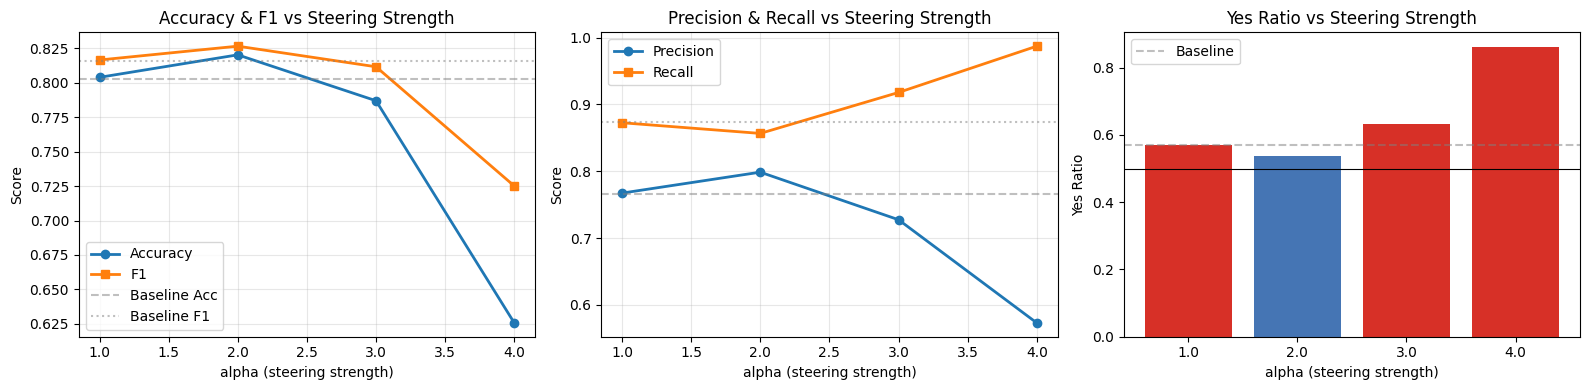

In [13]:
# --- Plot metrics vs alpha ---
alphas_sorted = sorted([a for a in steered_results.keys() if a > 0])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy + F1
ax = axes[0]
accs = [metrics_summary[a]['accuracy'] for a in alphas_sorted]
f1s  = [metrics_summary[a]['F1'] for a in alphas_sorted]
ax.plot(alphas_sorted, accs, 'o-', label='Accuracy', linewidth=2, markersize=6)
ax.plot(alphas_sorted, f1s,  's-', label='F1',       linewidth=2, markersize=6)
ax.axhline(y=metrics_summary[0.0]['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Baseline Acc')
ax.axhline(y=metrics_summary[0.0]['F1'],      color='gray', linestyle=':',  alpha=0.5, label='Baseline F1')
ax.set_xlabel('alpha (steering strength)')
ax.set_ylabel('Score')
ax.set_title('Accuracy & F1 vs Steering Strength')
ax.legend()
ax.grid(True, alpha=0.3)

# Precision + Recall
ax = axes[1]
precs = [metrics_summary[a]['precision'] for a in alphas_sorted]
recs  = [metrics_summary[a]['recall']    for a in alphas_sorted]
ax.plot(alphas_sorted, precs, 'o-', label='Precision', linewidth=2, markersize=6)
ax.plot(alphas_sorted, recs,  's-', label='Recall',    linewidth=2, markersize=6)
ax.axhline(y=metrics_summary[0.0]['precision'], color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=metrics_summary[0.0]['recall'],    color='gray', linestyle=':',  alpha=0.5)
ax.set_xlabel('alpha (steering strength)')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Steering Strength')
ax.legend()
ax.grid(True, alpha=0.3)

# Yes ratio
ax = axes[2]
yes_ratios = [metrics_summary[a]['yes_ratio'] for a in alphas_sorted]
bar_colors = ['#4575b4' if r < 0.55 else '#d73027' for r in yes_ratios]
ax.bar(range(len(alphas_sorted)), yes_ratios, color=bar_colors)
ax.set_xticks(range(len(alphas_sorted)))
ax.set_xticklabels([f'{a:.1f}' for a in alphas_sorted])
ax.axhline(y=0.5, color='black', linestyle='-', linewidth=0.8)
ax.axhline(y=metrics_summary[0.0]['yes_ratio'], color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.set_xlabel('alpha (steering strength)')
ax.set_ylabel('Yes Ratio')
ax.set_title('Yes Ratio vs Steering Strength')
ax.legend()

plt.tight_layout()
plt.show()